# Load recognition model

In [1]:
from transformers import TableTransformerForObjectDetection

structure_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-structure-recognition-v1.1-all")
structure_model.to("cuda")


/home/bas/Documents/Visual Code Repo's/BelHisFirm-BelHisHAAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TableTransformerForObjectDetection(
  (model): TableTransformerModel(
    (backbone): TableTransformerConvModel(
      (conv_encoder): TableTransformerConvEncoder(
        (model): ResNetBackbone(
          (embedder): ResNetEmbeddings(
            (embedder): ResNetConvLayer(
              (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
              (normalization): TableTransformerFrozenBatchNorm2d()
              (activation): ReLU()
            )
            (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          )
          (encoder): ResNetEncoder(
            (stages): ModuleList(
              (0): ResNetStage(
                (layers): Sequential(
                  (0): ResNetBasicLayer(
                    (shortcut): Identity()
                    (layer): Sequential(
                      (0): ResNetConvLayer(
                        (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(

In [2]:
from torchvision import transforms

class MaxResize(object):
    def __init__(self, max_size):
        self.max_size = max_size

    def __call__(self, image):
        width, height = image.size
        current_max_size = max(width, height)
        scale = self.max_size / current_max_size
        resized_image = image.resize((int(round(scale*width)), int(round(scale*height))))

        return resized_image

structure_transform = transforms.Compose([
    MaxResize(800),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

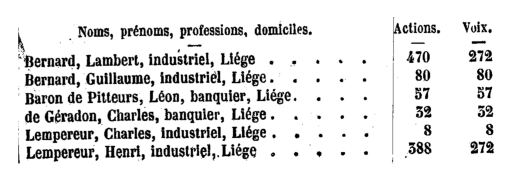

In [3]:
from PIL import Image

cropped_table = Image.open("LabelStudio/output/cropped_cd4dc748-1905_1_1629_page_6.png_346.png").convert("RGB")

from matplotlib import pyplot as plt
plt.imshow(cropped_table)
plt.axis('off')
plt.show()

In [4]:
pixel_values = structure_transform(cropped_table).unsqueeze(0)
pixel_values = pixel_values.to("cuda")
print(pixel_values.shape)

torch.Size([1, 3, 261, 800])


In [5]:
import torch

with torch.no_grad():
  outputs = structure_model(pixel_values)

In [6]:
# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(-1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h), (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)


def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

def outputs_to_objects(outputs, img_size, id2label):
    m = outputs.logits.softmax(-1).max(-1)
    pred_labels = list(m.indices.detach().cpu().numpy())[0]
    pred_scores = list(m.values.detach().cpu().numpy())[0]
    pred_bboxes = outputs['pred_boxes'].detach().cpu()[0]
    pred_bboxes = [elem.tolist() for elem in rescale_bboxes(pred_bboxes, img_size)]

    objects = []
    for label, score, bbox in zip(pred_labels, pred_scores, pred_bboxes):
        class_label = id2label[int(label)]
        if not class_label == 'no object':
            objects.append({'label': class_label, 'score': float(score),
                            'bbox': [float(elem) for elem in bbox]})

    return objects

In [7]:
structure_id2label = structure_model.config.id2label
structure_id2label[len(structure_id2label)] = "no object"

cells = outputs_to_objects(outputs, cropped_table.size, structure_id2label)

rows = 0
columns = 0

for cell in cells:
    label = cell["label"]
    if label == "table column":
        columns += 1
    if label == "table row":
          rows += 1


print(cells)

[{'label': 'table column', 'score': 0.9990767240524292, 'bbox': [887.5209350585938, 21.362075805664062, 1075.07080078125, 364.637451171875]}, {'label': 'table column', 'score': 0.7037278413772583, 'bbox': [723.1513061523438, 21.419700622558594, 768.2606811523438, 364.289794921875]}, {'label': 'table column', 'score': 0.9307754039764404, 'bbox': [769.2352294921875, 21.193910598754883, 822.0503540039062, 364.9781494140625]}, {'label': 'table column', 'score': 0.9587953686714172, 'bbox': [820.519775390625, 21.1256046295166, 888.5332641601562, 364.50872802734375]}, {'label': 'table row', 'score': 0.5763173699378967, 'bbox': [19.023569107055664, 90.80506896972656, 1176.6900634765625, 138.64886474609375]}, {'label': 'table column', 'score': 0.9993560910224915, 'bbox': [1073.66650390625, 21.510517120361328, 1176.2857666015625, 364.68450927734375]}, {'label': 'table column header', 'score': 0.7117867469787598, 'bbox': [18.11442756652832, 21.002788543701172, 1176.6441650390625, 91.3880386352539

In [8]:
def plot_results(cells, class_to_visualize):

    if class_to_visualize not in structure_model.config.id2label.values():
      raise ValueError("Class should be one of the available classes")

    plt.figure(figsize=(16,10))
    plt.imshow(cropped_table)
    ax = plt.gca()

    for cell in cells:
        score = cell["score"]
        bbox = cell["bbox"]
        label = cell["label"]


        if label == class_to_visualize:
          xmin, ymin, xmax, ymax = tuple(bbox)

          ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color="red", linewidth=3))
          text = f'{cell["label"]}: {score:0.2f}'
          ax.text(xmin, ymin, text, fontsize=15,
                  bbox=dict(facecolor='yellow', alpha=0.5))
          plt.axis('off')

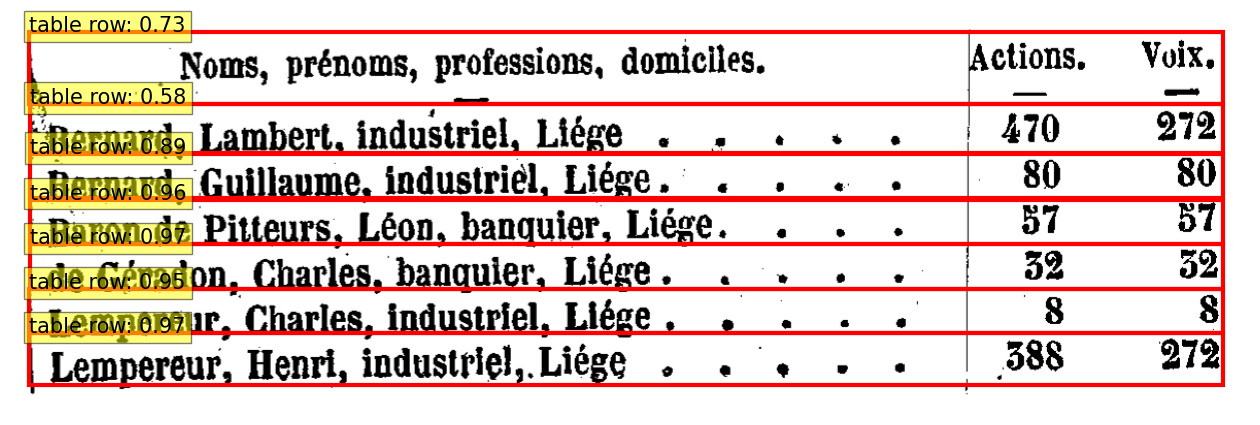

In [9]:
plot_results(cells, class_to_visualize="table row")

In [10]:
def get_cell_coordinates_by_row(table_data):
    # Extract rows and columns
    rows = [entry for entry in table_data if entry['label'] == 'table row']
    columns = [entry for entry in table_data if entry['label'] == 'table column']

    # Sort rows and columns by their Y and X coordinates, respectively
    rows.sort(key=lambda x: x['bbox'][1])
    columns.sort(key=lambda x: x['bbox'][0])

    # Function to find cell coordinates
    def find_cell_coordinates(row, column):
        cell_bbox = [column['bbox'][0], row['bbox'][1], column['bbox'][2], row['bbox'][3]]
        return cell_bbox

    # Generate cell coordinates and count cells in each row
    cell_coordinates = []

    for row in rows:
        row_cells = []
        for column in columns:
            cell_bbox = find_cell_coordinates(row, column)
            row_cells.append({'column': column['bbox'], 'cell': cell_bbox})

        # Sort cells in the row by X coordinate
        row_cells.sort(key=lambda x: x['column'][0])

        # Append row information to cell_coordinates
        cell_coordinates.append({'row': row['bbox'], 'cells': row_cells, 'cell_count': len(row_cells)})

    # Sort rows from top to bottom
    cell_coordinates.sort(key=lambda x: x['row'][1])

    return cell_coordinates

cell_coordinates = get_cell_coordinates_by_row(cells)

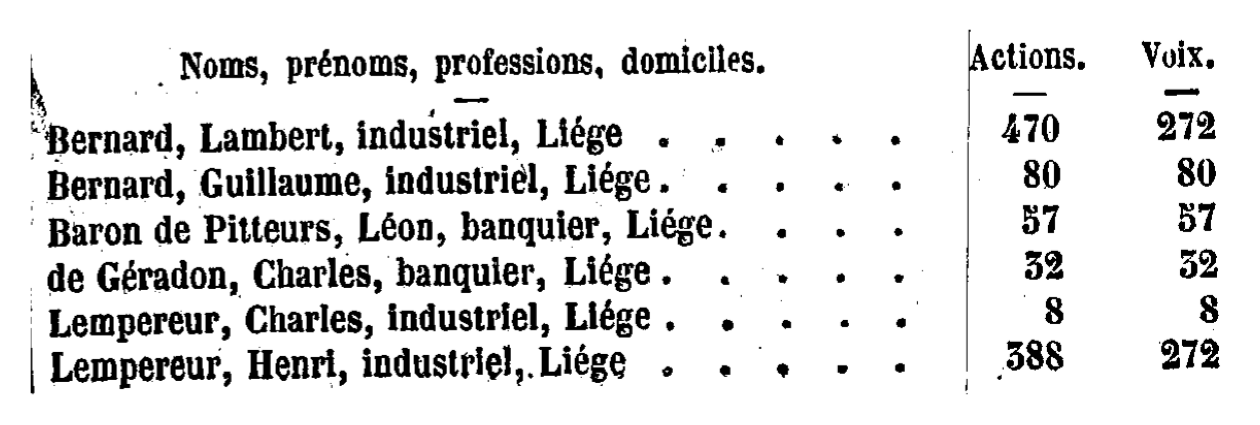

In [11]:
plt.figure(figsize=(16,10))
plt.imshow(cropped_table)
plt.axis('off') 
ax = plt.gca()

all_cropped_images = []
all_cropped_images_coords = []

for row in cell_coordinates:
    for cell in row["cells"]:
        xmin, ymin, xmax, ymax = cell["cell"]
        crop = cropped_table.crop((xmin, ymin, xmax, ymax))
        mean_coord = [(xmin + xmax) / 2, (ymin + ymax) / 2]
        all_cropped_images.append(crop)
        all_cropped_images_coords.append(mean_coord)


## OCR

In [19]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
import base64

model = Qwen2_5_VLForConditionalGeneration.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", torch_dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", min_pixels=128 * 28 * 28, max_pixels=1024 * 28 * 28)

Loading checkpoint shards: 100%|██████████| 5/5 [00:01<00:00,  2.99it/s]


In [24]:
import cv2 as cv
import numpy as np
import base64
import re

OCR_output = []


for idx, crop in enumerate(all_cropped_images):

    converted_crop_from_pil_to_cv = cv.cvtColor(np.array(crop), cv.COLOR_RGB2BGR)
    kernel = np.ones((2, 2), np.uint8)
    converted_crop_from_pil_to_cv = cv.erode(converted_crop_from_pil_to_cv, kernel, iterations=1)
    _, buffer = cv.imencode('.png', converted_crop_from_pil_to_cv)
    encoded_image = base64.b64encode(buffer).decode('utf-8')

    prompt = (
  "Transcribe ONLY the visible text in this image.\n"
  "- Do NOT guess or complete words from context.\n"
  "- If a word is cut off, output it exactly as seen.\n"
  "- Output a single line of text. No extra words, no commentary."
)
    
    message = [
                            {
                                "role": "user",
                                "content": [
                                    {"type": "image", "image": f"data:image/png;base64,{encoded_image}"},
                                    {"type": "text", "text": prompt},
                                ],
                            }
                        ]
                    
    text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(message)
    inputs = processor(
                            text=[text],
                            images=image_inputs,
                            videos=video_inputs,
                            padding=True,
                            return_tensors="pt",
                        )
    inputs = inputs.to("cuda")

    generated_ids = model.generate(**inputs, max_new_tokens=32)
    generated_ids_trimmed = [
                        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
                        ]
    text = processor.batch_decode(
                            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
                        )


    cleaned_text = re.sub(r"[^A-Za-zÀ-ÿ0-9,.\s]", "", text[0])
    # Remove dot/comma if it's the only character
    if cleaned_text in [".", ","]:
        cleaned_text = ""
    if cleaned_text and ("the contents" not in cleaned_text.lower()) and ("the image" not in cleaned_text.lower()) and ("the quick brown fox" not in cleaned_text.lower()) and ("none" not in cleaned_text.lower()):
        print(f"OCR output for cell {idx}: {cleaned_text}")
        OCR_output.append((cleaned_text, all_cropped_images_coords[idx]))




OCR output for cell 0: Noms, prénoms, professions, domiciles.
OCR output for cell 4: Actions.
OCR output for cell 5: Voix.
OCR output for cell 6: Bernard, Lambert, industriel, Liége
OCR output for cell 10: 470
OCR output for cell 11: 272
OCR output for cell 12: Bernard. Guillaume, industriel, Liége.
OCR output for cell 16: 80
OCR output for cell 17: 80
OCR output for cell 18: Baron de Pitteurs, Léon, banquier, Liége.
OCR output for cell 22: 57
OCR output for cell 23: 57
OCR output for cell 24: de Gérandon, Charles, banquier, Liége .
OCR output for cell 28: 32
OCR output for cell 29: 32
OCR output for cell 30: Lempereur, Charles, industriel, Liége
OCR output for cell 34: 8
OCR output for cell 35: 8
OCR output for cell 36: Lempereur, Henri, industriel, Liége
OCR output for cell 40: 388
OCR output for cell 41: 272


# Reconstruct Excel from coords

In [25]:

img_width, img_height = cropped_table.size

def normalize_coords(coord, img_width, img_height):
    x, y = coord
    norm_x = x / img_width
    norm_y = y / img_height
    return (norm_x, norm_y)

real_coords_normalized = [normalize_coords(coord, img_width, img_height) 
                          for text, coord in OCR_output]

def calculate_mean_artificial_coords(amount_of_columns, amount_of_rows):
    artificial_coords = []
    normalized_c = 1 / amount_of_columns
    normalized_r = 1 / amount_of_rows

    print("Step size:", normalized_c, normalized_r)
    for r in range(amount_of_rows):
        for c in range(amount_of_columns):
            artificial_coords.append(((c + 0.5) * normalized_c,
                                      (r + 0.5) * normalized_r))
    return artificial_coords

artificial_coords = calculate_mean_artificial_coords(columns, rows)

aligned = []
for artificial, real in zip(artificial_coords, real_coords_normalized):
    aligned.append((artificial, real))

    


Step size: 0.16666666666666666 0.14285714285714285


In [26]:
import numpy as np
from collections import defaultdict

import numpy as np

def assign_nearest_per_cell(artificial_coords, real_coords_norm, texts, rows, columns, max_dist=None):
    """
    artificial_coords: list[(ax, ay)] normalized in [0,1], length == rows*columns, row-major
    real_coords_norm: list[(rx, ry)] normalized [0,1] for each OCR text
    texts: list[str] same length as real_coords_norm
    rows, columns: ints
    max_dist: optional float in normalized units; if nearest distance > max_dist, leave empty
    """
    A = np.asarray(artificial_coords, dtype=float)             # (N,2)
    R = np.asarray(real_coords_norm, dtype=float)              # (M,2)
    used = np.zeros(len(R), dtype=bool)

    table = np.empty((rows, columns), dtype=object)
    table[:] = ""

    for i, (ax, ay) in enumerate(A):
        # distances to all *unused* real points
        diffs = R - np.array([ax, ay])
        dists = np.linalg.norm(diffs, axis=1)
        dists[used] = np.inf  # mask out already used points

        j = int(np.argmin(dists))
        d = dists[j]

        if np.isfinite(d) and (max_dist is None or d <= max_dist):
            r, c = divmod(i, columns)
            # If multiple items can go into one cell, append:
            table[r, c] = (table[r, c] + "\n" if table[r, c] else "") + str(texts[j])
            used[j] = True
        # else: leave cell empty

    return table


real_coords_norm = [(x / img_width, y / img_height) for _, (x, y) in OCR_output]
texts = [t for t, _ in OCR_output]

table = assign_nearest_per_cell(
    artificial_coords,
    real_coords_norm,
    texts,
    rows,
    columns,
    max_dist=0.12  # optional safeguard; tweak as needed
)
print(table)


[['' 'Noms, prénoms, professions, domiciles.' '' '' 'Actions.' 'Voix.']
 ['' 'Bernard, Lambert, industriel, Liége' '' '' '470' '272']
 ['' 'Bernard. Guillaume, industriel, Liége.' '' '' '80' '80']
 ['' 'Baron de Pitteurs, Léon, banquier, Liége.' '' '' '57' '57']
 ['' 'de Gérandon, Charles, banquier, Liége .' '' '' '32' '32']
 ['' 'Lempereur, Charles, industriel, Liége' '' '' '8' '8']
 ['' 'Lempereur, Henri, industriel, Liége' '' '' '388' '272']]


  0                                          1 2 3         4      5
0       Noms, prénoms, professions, domiciles.      Actions.  Voix.
1          Bernard, Lambert, industriel, Liége           470    272
2       Bernard. Guillaume, industriel, Liége.            80     80
3    Baron de Pitteurs, Léon, banquier, Liége.            57     57
4      de Gérandon, Charles, banquier, Liége .            32     32
5        Lempereur, Charles, industriel, Liége             8      8
6          Lempereur, Henri, industriel, Liége           388    272


(np.float64(-0.5), np.float64(1202.5), np.float64(392.5), np.float64(-0.5))

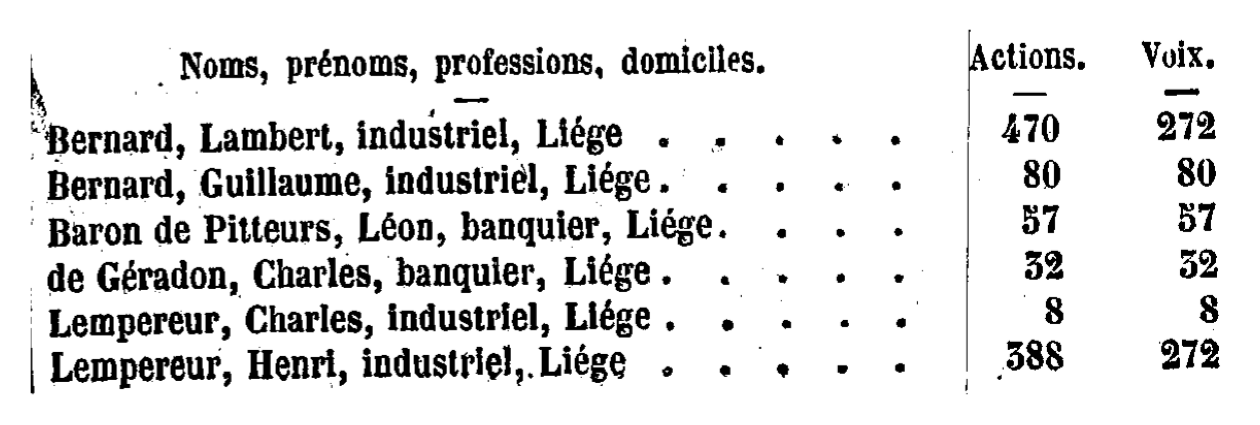

In [30]:
import pandas as pd

df = pd.DataFrame(table)
print(df)
df.to_excel("output_table.xlsx", index=False)

plt.figure(figsize=(16,10))
plt.imshow(cropped_table)
plt.axis('off')
